# Hands-on 1 — Foundations: JAX, standardized models and your first inference

**Course:** NIFTy in a day · **Session:** 10:15 – 11:30 · **Library:** `nifty.re` (NIFTy 9.x)

**Goals of this notebook**
1. Be fluent with the four JAX ideas NIFTy.re is built on: arrays, random keys, `jit`/`grad`/`vmap`, and *pytrees*.
2. Understand **standardization**: every NIFTy model is a function $s(\xi)$ of latent parameters $\xi \sim \mathcal{N}(0, 1)$.
3. Write a `jft.Model`, wrap it in a likelihood, and run `jft.optimize_kl` (MAP and MGVI) end to end.

Work through the cells in order. Cells marked **✏️ Exercise** are for you; solutions are at the very bottom.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import numpy as np

import nifty.re as jft

# NIFTy strongly recommends double precision: CG solvers and log-determinants are fragile in float32.
jax.config.update("jax_enable_x64", True)
plt.rcParams["figure.dpi"] = 90
print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0)]


## 1. JAX in ten minutes

### 1.1 Random numbers are explicit
JAX has no global random state. You carry a **key** around and `split` it whenever you need fresh randomness.
This makes every NIFTy run exactly reproducible — and it is why almost every NIFTy function takes `key=`.

In [2]:
key = random.PRNGKey(42)
key, k1, k2 = random.split(key, 3)
print(random.normal(k1, (3,)))
print(random.normal(k1, (3,)), "<- same key, same numbers")
print(random.normal(k2, (3,)), "<- new key, new numbers")

[ 0.64989201  0.11847861 -1.55571939]
[ 0.64989201  0.11847861 -1.55571939] <- same key, same numbers
[-0.32162797  0.42463557  0.85070082] <- new key, new numbers


### 1.2 `grad`, `jit`, `vmap`
NIFTy needs gradients (for the optimizer) and Jacobian-vector products (for the Fisher metric). JAX gives you both for free.

In [3]:
def f(x):
    return jnp.sum(jnp.sin(x) ** 2)

x = jnp.linspace(0.0, 1.0, 5)
print("f(x)       =", f(x))
print("grad f(x)  =", jax.grad(f)(x))
print("analytic   =", 2 * jnp.sin(x) * jnp.cos(x))

f_fast = jax.jit(f)               # compiled with XLA on first call
batched = jax.vmap(f)             # maps over a leading batch axis
print("vmap:", batched(jnp.stack([x, 2 * x])))

f(x)       = 1.4637623835604634


grad f(x)  = [0.         0.47942554 0.84147098 0.99749499 0.90929743]


analytic   = [0.         0.47942554 0.84147098 0.99749499 0.90929743]
vmap: [1.46376238 2.75974032]


### 1.3 Pytrees and `jft.Vector`
A *pytree* is any nested structure of dicts/tuples/lists whose leaves are arrays. NIFTy latent parameters are
usually **dicts of arrays**, one entry per named model component. `jft.Vector` wraps a pytree so you can do
arithmetic on it as if it were one big vector.

In [4]:
p = {"a": jnp.ones(3), "b": jnp.array(2.0)}
q = {"a": jnp.arange(3.0), "b": jnp.array(-1.0)}
P, Q = jft.Vector(p), jft.Vector(q)
print("P + 2Q   =", (P + 2 * Q).tree)
print("<P, Q>   =", jft.vdot(P, Q))
print("size     =", jft.size(P))

P + 2Q   = {'a': Array([1., 3., 5.], dtype=float64), 'b': Array(0., dtype=float64, weak_type=True)}
<P, Q>   = 1.0
size     = 4


## 2. Standardization — the single most important idea in NIFTy

NIFTy's inference algorithms (MGVI, geoVI) approximate the posterior with Gaussians **in latent space**.
That works best when the prior there is $\mathcal{N}(0, \mathbb{1})$. So NIFTy asks you to write every prior
as a deterministic transform of standard-normal parameters:

$$ s = s(\xi), \qquad \xi \sim \mathcal{N}(0,\mathbb{1}), \qquad s(\xi) = \left(\mathrm{CDF}^{-1}_{P(s)} \circ \mathrm{CDF}_{\mathcal{N}}\right)(\xi). $$

The prior classes in `nifty.re` (`NormalPrior`, `LogNormalPrior`, `UniformPrior`, `InvGammaPrior`, `LaplacePrior`, …)
are exactly these maps. Let's verify for a log-normal with mean 4 and std 3.

domain (latent): {'a': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>)}
target (signal): ShapeDtypeStruct(shape=(), dtype=float64)


sample mean = 4.005 (want 4)   sample std = 3.039 (want 3)


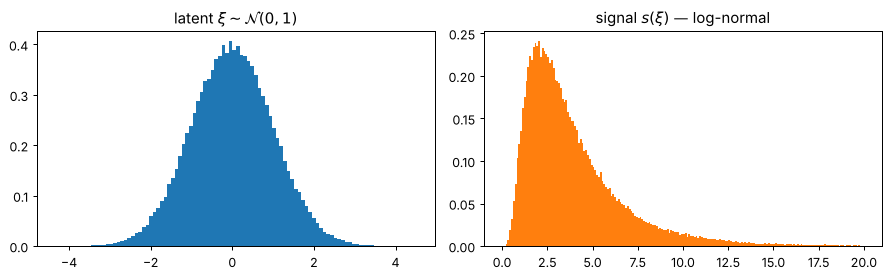

In [5]:
a = jft.LogNormalPrior(mean=4.0, std=3.0, name="a")
print("domain (latent):", a.domain)
print("target (signal):", a.target)

key, sk = random.split(key)
xi = random.normal(sk, (100_000,))
s = jax.vmap(lambda z: a({"a": z}))(xi)
print(f"sample mean = {s.mean():.3f} (want 4)   sample std = {s.std():.3f} (want 3)")

fig, axs = plt.subplots(1, 2, figsize=(10, 3.2))
axs[0].hist(xi, 100, density=True, color="tab:blue"); axs[0].set_title(r"latent $\xi \sim \mathcal{N}(0,1)$")
axs[1].hist(s, 200, density=True, range=(0, 20), color="tab:orange"); axs[1].set_title(r"signal $s(\xi)$ — log-normal")
plt.tight_layout(); plt.show()

Notice `a.domain` is a dict `{'a': ShapeDtypeStruct(...)}`: the `name=` you give a prior becomes the key of
its latent parameter. **Names must be unique within a model** — they are how NIFTy keeps track of parameters.

## 3. Writing a `jft.Model`: Bayesian linear regression

Data model: $d_i = a\,x_i + b + n_i$, with $a \sim \text{LogNormal}(4, 3)$ (we know it is positive),
$b \sim \mathcal{N}(0, 3^2)$ and Gaussian noise $n_i \sim \mathcal{N}(0, \sigma_n^2)$.

A `jft.Model` is "just a function with bookkeeping": `__call__(xi)` does the forward computation, and
`init=` tells NIFTy which latent parameters exist (and how to initialise them). Combine the `init`s of sub-models with `|`.

true slope: 4.02629794174195  true intercept: 1.9423678373951896


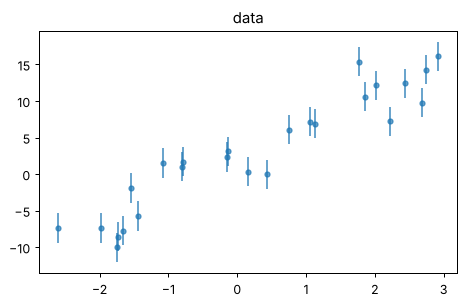

In [6]:
class Line(jft.Model):
    def __init__(self, x):
        self.x = x
        self.slope = jft.LogNormalPrior(4.0, 3.0, name="slope")
        self.intercept = jft.NormalPrior(0.0, 3.0, name="intercept")
        super().__init__(init=self.slope.init | self.intercept.init)

    def __call__(self, xi, *, x=None):
        x = self.x if x is None else x
        return self.slope(xi) * x + self.intercept(xi)

# Synthetic data from a known truth
key, k_x, k_truth, k_noise = random.split(key, 4)
x_data = jnp.sort(random.uniform(k_x, (25,), minval=-3, maxval=3))
line = Line(x_data)
xi_truth = line.init(k_truth)
sigma_n = 2.0
d = line(xi_truth) + sigma_n * random.normal(k_noise, x_data.shape)
print("true slope:", float(line.slope(xi_truth)), " true intercept:", float(line.intercept(xi_truth)))

plt.figure(figsize=(6, 3.5)); plt.errorbar(x_data, d, sigma_n, fmt="o", ms=4, alpha=0.7)
plt.title("data"); plt.show()

## 4. The likelihood and the information Hamiltonian

`jft.Gaussian(data, noise_cov_inv)` builds $-\ln P(d\,|\,r)$ as a function of the *model response* $r$.
`.amend(model)` composes it with your model, so it becomes a function of $\xi$:

$$ \mathcal{H}(d|\xi) = \tfrac12 \big(d - r(\xi)\big)^\dagger N^{-1} \big(d - r(\xi)\big) + \text{const}. $$

The full **information Hamiltonian** that NIFTy minimises / samples is $\mathcal{H}(d,\xi) = \mathcal{H}(d|\xi) + \tfrac12 \xi^\dagger\xi$.
You never write the prior term — NIFTy adds it because it *knows* the latent prior is standard normal.

Note: `noise_cov_inv` is a **function** (an operator), not a matrix. This is a NIFTy theme — operators are applied, never stored.

In [7]:
lh = jft.Gaussian(d, noise_cov_inv=lambda r: r / sigma_n**2).amend(line)
print("likelihood domain:", lh.domain)

xi0 = jft.Vector(lh.init(random.PRNGKey(0)))
print("H(d|xi0)          =", lh(xi0))
print("grad of full H    =", jax.grad(lambda z: lh(z) + 0.5 * jft.vdot(z, z))(xi0).tree)

# The Fisher metric M(xi) = J^T N^{-1} J (+1 for the prior) is what MGVI uses as approximate posterior precision:
print("metric applied to xi0:", lh.metric(xi0, xi0).tree)

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


likelihood domain: {'intercept': ShapeDtypeStruct(shape=(), dtype=float64), 'slope': ShapeDtypeStruct(shape=(), dtype=float64)}
H(d|xi0)          = 126.02594919659663


grad of full H    = {'intercept': Array(-101.45650295, dtype=float64), 'slope': Array(-64.70664371, dtype=float64)}


metric applied to xi0: {'intercept': Array(-56.64116186, dtype=float64), 'slope': Array(-13.91533996, dtype=float64)}


## 5. Inference with `jft.optimize_kl`

`optimize_kl` is the workhorse. One call can do:
* **MAP** — `n_samples=0`: just minimise $\mathcal{H}(d,\xi)$.
* **MGVI** — `sample_mode="linear_resample"`: Gaussian approximation with covariance = inverse Fisher metric.
* **geoVI** — `sample_mode="nonlinear_resample"` (the default): samples are pushed through a non-linear coordinate transform.

The three nested solvers each have their own kwargs:
| kwargs | what it solves | typical knob |
|---|---|---|
| `draw_linear_kwargs` | CG solve to draw the linear (MGVI) sample $\sim \mathcal{N}(0, M^{-1})$ | `cg_kwargs=dict(absdelta=..., maxiter=...)` |
| `nonlinearly_update_kwargs` | Newton-CG that bends each sample (geoVI only) | `minimize_kwargs=dict(xtol=..., maxiter=...)` |
| `kl_kwargs` | Newton-CG that moves the mean to minimise the KL | `minimize_kwargs=dict(xtol=..., maxiter=...)` |

In [8]:
delta = 1e-5
solver_kwargs = dict(
    draw_linear_kwargs=dict(cg_name=None, cg_kwargs=dict(absdelta=delta * jft.size(lh.domain) / 10, maxiter=100)),
    nonlinearly_update_kwargs=dict(minimize_kwargs=dict(name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=10)),
    kl_kwargs=dict(minimize_kwargs=dict(name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=30)),
)

key, k_init, k_map, k_mgvi, k_geo = random.split(key, 5)
init = jft.Vector(lh.init(k_init))

# --- MAP ---
samples_map, _ = jft.optimize_kl(lh, init, n_total_iterations=3, n_samples=0, key=k_map, **solver_kwargs)
xi_map = samples_map.pos

# --- MGVI ---
samples_mgvi, _ = jft.optimize_kl(lh, init, n_total_iterations=5, n_samples=20, key=k_mgvi,
                                  sample_mode="linear_resample", **solver_kwargs)
# --- geoVI ---
samples_geo, _ = jft.optimize_kl(lh, init, n_total_iterations=5, n_samples=20, key=k_geo,
                                 sample_mode="nonlinear_resample", **solver_kwargs)

for name, smp in [("MGVI", samples_mgvi), ("geoVI", samples_geo)]:
    sl_m, sl_s = jft.mean_and_std(tuple(line.slope(s) for s in smp))
    ic_m, ic_s = jft.mean_and_std(tuple(line.intercept(s) for s in smp))
    print(f"{name:6s} slope = {float(sl_m):.3f} ± {float(sl_s):.3f}   intercept = {float(ic_m):.3f} ± {float(ic_s):.3f}")
print(f"MAP    slope = {float(line.slope(xi_map)):.3f}            intercept = {float(line.intercept(xi_map)):.3f}")

<frozen genericpath>:39: RuntimeWarning: bool is used as a file descriptor
OPTIMIZE_KL: Starting 0001


OPTIMIZE_KL: Iteration 0001 E:+2.2801e+01
OPTIMIZE_KL: #(KL minimization steps) 5
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.8±     0.0, avg:   +0.018±     0.0, #dof:     25'

OPTIMIZE_KL: Prior residual(s):
intercept               :: 'reduced Chi²:    0.45±     0.0, avg:    +0.67±     0.0, #dof:      1'
slope                   :: 'reduced Chi²:    0.21±     0.0, avg:    +0.45±     0.0, #dof:      1'




OPTIMIZE_KL: Starting 0002


OPTIMIZE_KL: Iteration 0002 E:+2.2801e+01
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.8±     0.0, avg:   +0.018±     0.0, #dof:     25'

OPTIMIZE_KL: Prior residual(s):
intercept               :: 'reduced Chi²:    0.45±     0.0, avg:    +0.67±     0.0, #dof:      1'
slope                   :: 'reduced Chi²:    0.21±     0.0, avg:    +0.45±     0.0, #dof:      1'




OPTIMIZE_KL: Starting 0003


...

CG: gamma=0, converged!


OPTIMIZE_KL: Iteration 0004 E:+2.3622e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (2, 2, 3, 3, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 3, 3, 2, 2)
OPTIMIZE_KL: #(KL minimization steps) 2
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.9±   0.062, avg:   +0.018±     0.2, #dof:     25'

OPTIMIZE_KL: Prior residual(s):
intercept               :: 'reduced Chi²:    0.47±    0.18, avg:    +0.67±    0.14, #dof:      1'
slope                   :: 'reduced Chi²:    0.21±   0.057, avg:    +0.45±   0.064, #dof:      1'




OPTIMIZE_KL: Starting 0005


OPTIMIZE_KL: Iteration 0005 E:+2.3647e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 2, 2, 2, 2, 3, 2)
OPTIMIZE_KL: #(KL minimization steps) 2
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.9±    0.06, avg:   +0.018±    0.19, #dof:     25'

OPTIMIZE_KL: Prior residual(s):
intercept               :: 'reduced Chi²:    0.46±    0.18, avg:    +0.67±    0.13, #dof:      1'
slope                   :: 'reduced Chi²:    0.21±   0.063, avg:    +0.45±   0.071, #dof:      1'




MGVI   slope = 4.317 ± 0.242   intercept = 2.008 ± 0.305
geoVI  slope = 4.321 ± 0.207   intercept = 2.007 ± 0.400
MAP    slope = 4.330            intercept = 2.005


### Anatomy of `Samples`
* `samples.pos` — the latent mean $\bar\xi$ of the variational Gaussian.
* iterating `for s in samples` yields $\bar\xi \pm \delta\xi_i$ — **antithetic (mirrored) pairs**, which cancel odd moments and halve the variance of the KL estimate. With `n_samples=20` you get 40 samples.
* `samples.samples` — the same thing stacked along a leading axis (handy with `jax.vmap`).

number of samples: 40


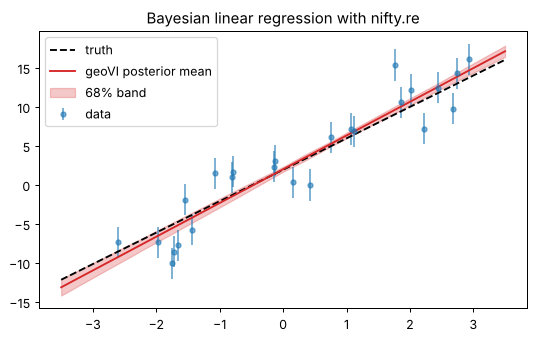

In [9]:
print("number of samples:", len(samples_geo))
x_plot = jnp.linspace(-3.5, 3.5, 200)
y_smp = jax.vmap(lambda s: line(s, x=x_plot))(samples_geo.samples)

plt.figure(figsize=(7, 4))
plt.errorbar(x_data, d, sigma_n, fmt="o", ms=4, alpha=0.6, label="data")
plt.plot(x_plot, line(xi_truth, x=x_plot), "k--", label="truth")
plt.plot(x_plot, y_smp.mean(0), "C3", label="geoVI posterior mean")
plt.fill_between(x_plot, *np.quantile(y_smp, [0.16, 0.84], axis=0), color="C3", alpha=0.25, label="68% band")
plt.legend(); plt.title("Bayesian linear regression with nifty.re"); plt.show()

## ✏️ Exercises

**E1.1 — Priors.** Plot histograms of 50 000 prior samples of `jft.UniformPrior(-1, 1, name="u")` and `jft.InvGammaPrior(a=3, scale=2, name="g")`.
Check visually that a standard normal $\xi$ is mapped to the advertised distribution.

**E1.2 — Quadratic model.** Write a model `Parabola` (same as `Line`) with an extra coefficient $c\,x^2$, $c \sim \mathcal{N}(0, 1)$.
Fit it to the same data. Does the posterior of $c$ include 0? (It should — the truth is a line.)

**E1.3 — Learn the noise.** Pretend you don't know $\sigma_n$. Give it a prior `jft.LogNormalPrior(1.0, 1.0, name="sigma")` and use
`jft.VariableCovarianceGaussian(d).amend(model)` where the model now returns the tuple `(prediction, 1/sigma)`
(the second entry is the **inverse standard deviation**). Recover $\sigma_n \approx 2$.

**E1.4 — Think.** Why is `jft.Vector(...)` needed around the initial position but not around the samples?
(Hint: what does `optimize_kl` do arithmetically with the position?)

In [10]:
# Your work here

---
## Solutions

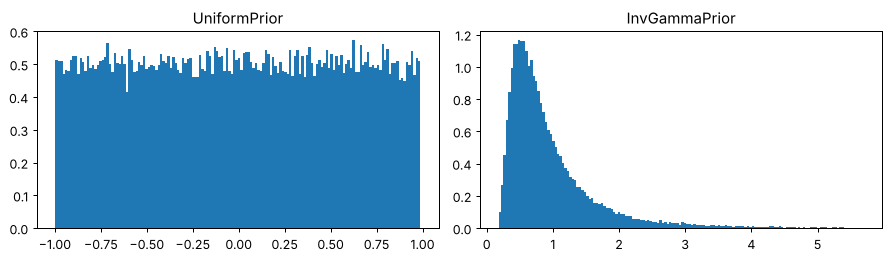

In [11]:
# E1.1
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
xi = random.normal(random.PRNGKey(1), (50_000,))
for ax, prior, nm in [(axs[0], jft.UniformPrior(-1.0, 1.0, name="u"), "u"),
                      (axs[1], jft.InvGammaPrior(a=3.0, scale=2.0, name="g"), "g")]:
    v = jax.vmap(lambda z: prior({nm: z}))(xi)
    ax.hist(v, 150, density=True, range=(float(jnp.quantile(v, 0.001)), float(jnp.quantile(v, 0.995))))
    ax.set_title(type(prior).__name__)
plt.tight_layout(); plt.show()

In [12]:
# E1.2
class Parabola(jft.Model):
    def __init__(self, x):
        self.x = x
        self.slope = jft.LogNormalPrior(4.0, 3.0, name="slope")
        self.intercept = jft.NormalPrior(0.0, 3.0, name="intercept")
        self.curv = jft.NormalPrior(0.0, 1.0, name="curv")
        super().__init__(init=self.slope.init | self.intercept.init | self.curv.init)

    def __call__(self, xi, *, x=None):
        x = self.x if x is None else x
        return self.slope(xi) * x + self.intercept(xi) + self.curv(xi) * x**2

par = Parabola(x_data)
lh_p = jft.Gaussian(d, noise_cov_inv=lambda r: r / sigma_n**2).amend(par)
smp_p, _ = jft.optimize_kl(lh_p, jft.Vector(lh_p.init(random.PRNGKey(3))), n_total_iterations=5,
                           n_samples=20, key=random.PRNGKey(4), **solver_kwargs)
c_m, c_s = jft.mean_and_std(tuple(par.curv(s) for s in smp_p))
print(f"curvature c = {float(c_m):.3f} ± {float(c_s):.3f}  -> consistent with 0: {abs(float(c_m)) < 2 * float(c_s)}")

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


OPTIMIZE_KL: Starting 0001


OPTIMIZE_KL: Iteration 0001 E:+2.7828e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (2, 2, 3, 3, 3, 3, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 3, 3, 3, 3, 2, 2, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2)
OPTIMIZE_KL: #(KL minimization steps) 5
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     2.2±    0.45, avg:    +0.02±    0.21, #dof:     25'

OPTIMIZE_KL: Prior residual(s):
curv                    :: 'reduced Chi²:   0.032±   0.043, avg:   -0.087±    0.16, #dof:      1'
intercept               :: 'reduced Chi²:    0.63±    0.37, avg:    +0.76±    0.23, #dof:      1'
slope                   :: 'reduced Chi²:    0.23±     0.2, avg:    +0.41±    0.26, #dof:      1'




OPTIMIZE_KL: Starting 0002


OPTIMIZE_KL: Iteration 0002 E:+2.4088e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (3, 3, 3, 3, 3, 3, 2, 2, 1, 1, 2, 2, 3, 3, 2, 2, 3, 3, 2, 2, 2, 2, 3, 3, 1, 1, 2, 2, 3, 3, 3, 3, 3, 3, 2, 2, 3, 3, 2, 2)
OPTIMIZE_KL: #(KL minimization steps) 3
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.9±   0.093, avg:   +0.021±    0.16, #dof:     25'

OPTIMIZE_KL: Prior residual(s):
curv                    :: 'reduced Chi²:    0.05±   0.069, avg:    -0.12±    0.19, #dof:      1'
intercept               :: 'reduced Chi²:    0.64±    0.31, avg:    +0.78±     0.2, #dof:      1'
slope                   :: 'reduced Chi²:    0.23±   0.091, avg:    +0.47±   0.097, #dof:      1'




...

OPTIMIZE_KL: Starting 0004


OPTIMIZE_KL: Iteration 0004 E:+2.3732e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 3, 3, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2)
OPTIMIZE_KL: #(KL minimization steps) 2
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.9±   0.081, avg:   +0.021±    0.18, #dof:     25'

OPTIMIZE_KL: Prior residual(s):
curv                    :: 'reduced Chi²:   0.045±    0.06, avg:    -0.12±    0.18, #dof:      1'
intercept               :: 'reduced Chi²:    0.65±    0.32, avg:    +0.78±     0.2, #dof:      1'
slope                   :: 'reduced Chi²:    0.23±   0.059, avg:    +0.48±   0.062, #dof:      1'




OPTIMIZE_KL: Starting 0005


OPTIMIZE_KL: Iteration 0005 E:+2.3924e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (2, 2, 2, 3, 2, 2, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2)
OPTIMIZE_KL: #(KL minimization steps) 2
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.9±   0.077, avg:   +0.021±    0.21, #dof:     25'

OPTIMIZE_KL: Prior residual(s):
curv                    :: 'reduced Chi²:   0.042±   0.059, avg:    -0.12±    0.17, #dof:      1'
intercept               :: 'reduced Chi²:    0.66±    0.35, avg:    +0.78±    0.22, #dof:      1'
slope                   :: 'reduced Chi²:    0.23±   0.068, avg:    +0.47±   0.072, #dof:      1'




curvature c = -0.120 ± 0.169  -> consistent with 0: True


In [13]:
# E1.3
class LineWithNoise(jft.Model):
    def __init__(self, x):
        self.x = x
        self.slope = jft.LogNormalPrior(4.0, 3.0, name="slope")
        self.intercept = jft.NormalPrior(0.0, 3.0, name="intercept")
        self.sigma = jft.LogNormalPrior(1.0, 1.0, name="sigma")
        super().__init__(init=self.slope.init | self.intercept.init | self.sigma.init)

    def __call__(self, xi):
        prediction = self.slope(xi) * self.x + self.intercept(xi)
        inv_std = jnp.ones_like(prediction) / self.sigma(xi)   # must have the same shape as the data
        return prediction, inv_std   # (mean, inverse std) as VariableCovarianceGaussian expects

lwn = LineWithNoise(x_data)
lh_n = jft.VariableCovarianceGaussian(d).amend(lwn)
smp_n, _ = jft.optimize_kl(lh_n, jft.Vector(lh_n.init(random.PRNGKey(5))), n_total_iterations=6,
                           n_samples=20, key=random.PRNGKey(6), **solver_kwargs)
s_m, s_s = jft.mean_and_std(tuple(lwn.sigma(s) for s in smp_n))
print(f"inferred noise std = {float(s_m):.2f} ± {float(s_s):.2f}   (truth {sigma_n})")

OPTIMIZE_KL: Starting 0001


N: Iteration Limit Reached


N: Iteration Limit Reached


N: Iteration Limit Reached


N: Iteration Limit Reached


...

OPTIMIZE_KL: Starting 0005


OPTIMIZE_KL: Iteration 0005 E:+4.0692e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 9, 9, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 8, 8, 9, 9, 9, 10, 8, 8, 8, 7, 9, 9, 9, 9, 8, 8, 9, 9)
OPTIMIZE_KL: #(KL minimization steps) 4
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.1±    0.34, avg:   +0.012±    0.21, #dof:     25'

OPTIMIZE_KL: Prior residual(s):
intercept               :: 'reduced Chi²:    0.51±     0.3, avg:    +0.69±     0.2, #dof:      1'
sigma                   :: 'reduced Chi²:     2.7±    0.67, avg:     +1.6±     0.2, #dof:      1'
slope                   :: 'reduced Chi²:     0.2±     0.1, avg:    +0.43±    0.12, #dof:      1'




OPTIMIZE_KL: Starting 0006


OPTIMIZE_KL: Iteration 0006 E:+4.0864e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (8, 8, 8, 8, 9, 9, 9, 8, 8, 8, 8, 8, 8, 8, 10, 9, 9, 9, 8, 8, 9, 9, 6, 6, 9, 9, 8, 8, 7, 7, 9, 9, 8, 8, 7, 7, 8, 8, 9, 9)
OPTIMIZE_KL: #(KL minimization steps) 4
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.1±    0.33, avg:   +0.031±    0.26, #dof:     25'

OPTIMIZE_KL: Prior residual(s):
intercept               :: 'reduced Chi²:    0.48±    0.32, avg:    +0.65±    0.25, #dof:      1'
sigma                   :: 'reduced Chi²:     2.8±    0.62, avg:     +1.6±    0.19, #dof:      1'
slope                   :: 'reduced Chi²:    0.21±     0.1, avg:    +0.44±    0.12, #dof:      1'




inferred noise std = 2.82 ± 0.45   (truth 2.0)


**E1.4** `optimize_kl` adds, subtracts and scales positions (Newton steps, $\bar\xi \pm \delta\xi$). A plain dict
does not support `+` or `*`; `jft.Vector` gives the pytree vector-space arithmetic. The returned `Samples`
object already stores `jft.Vector`s internally.